# Лабораторна робота №4 - Візуалізація даних 2

**Завдання:** Інтерактивна візуалізація гармонічного сигналу `y(t) = A·sin(2π·f·t + φ)` з гаусівським шумом та фільтрацією (Butterworth low-pass).

> **Вимога до запуску:** ноутбук використовує `%matplotlib widget` - необхідний пакет `ipympl`.  
> Встановлення: `pip install ipympl`  
> Запустіть усі комірки зверху вниз.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

In [2]:
def harmonic_with_noise(amplitude, frequency, phase,
                        noise_mean, noise_covariance, show_noise,
                        t, noise=None):
    """
    Генерує гармонічний сигнал y(t) = A·sin(2π·f·t + φ) з накладеним шумом.

    Параметри
    ---------
    amplitude        : float    - амплітуда (A)
    frequency        : float    - частота, Гц (f)
    phase            : float    - фазовий зсув, рад (φ)
    noise_mean       : float    - математичне сподівання шуму (μ)
    noise_covariance : float    - дисперсія шуму (σ²)
    show_noise       : bool     - включити шум у відображуваний сигнал
    t                : ndarray  - масив часу
    noise            : ndarray | None
                         готовий масив шуму для повторного використання;
                         None → генерується новий

    Повертає
    --------
    clean  : ndarray - чиста гармоніка
    signal : ndarray - відображуваний сигнал (зашумлений або чистий)
    noise  : ndarray - масив шуму (для збереження між викликами)
    """
    clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    if noise is None:
        std = np.sqrt(max(noise_covariance, 1e-12))
        noise = np.random.normal(noise_mean, std, size=len(t))

    signal = (clean + noise) if show_noise else clean.copy()
    return clean, signal, noise


def apply_butter_lowpass(signal, cutoff_hz, fs_hz, order=4):
    """
    Фільтр нижніх частот Баттерворта (нульова фазова затримка - filtfilt).

    Параметри
    ---------
    signal     : ndarray - вхідний зашумлений сигнал
    cutoff_hz  : float   - гранична частота, Гц
    fs_hz      : float   - частота дискретизації, Гц
    order      : int     - порядок фільтра (за замовчуванням 4)

    Повертає
    --------
    ndarray - відфільтрований сигнал
    """
    nyq = 0.5 * fs_hz
    normal_cutoff = float(np.clip(cutoff_hz / nyq, 0.01, 0.99))
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

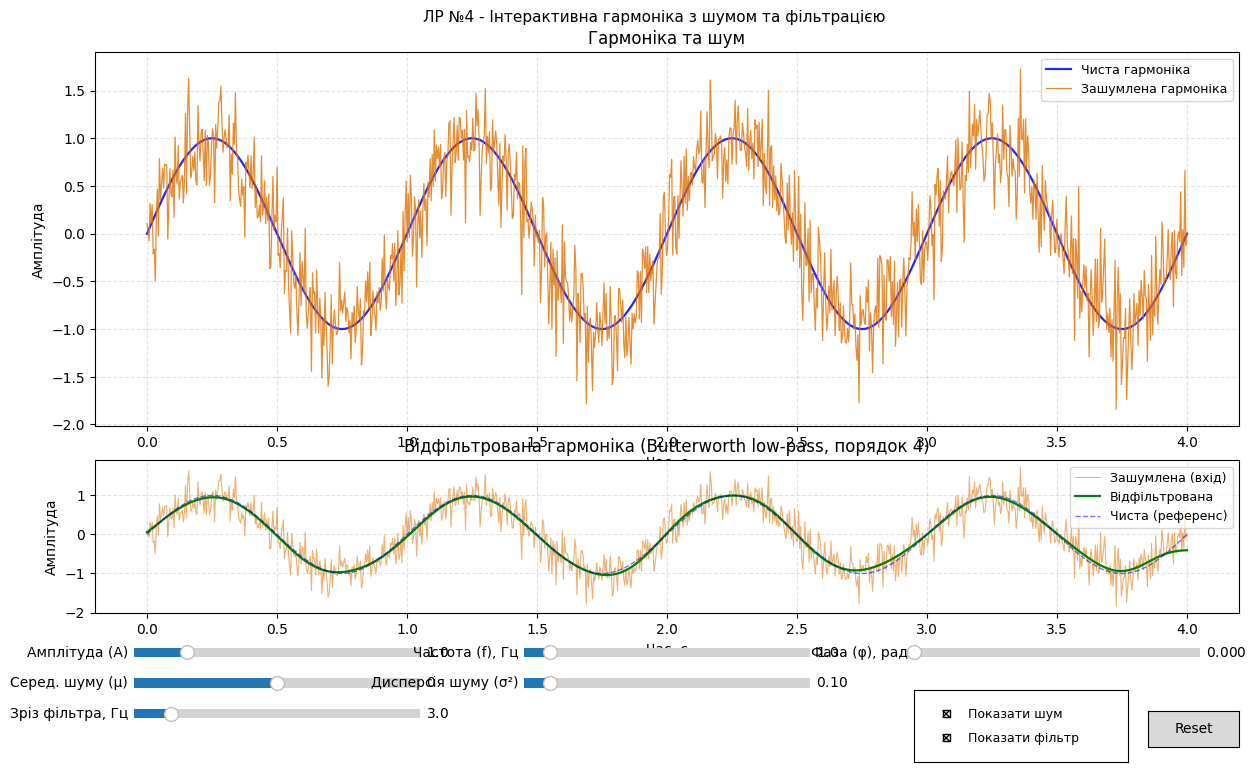

In [ ]:
#  Початкові параметри
DEFAULTS = dict(
    amplitude  = 1.0,
    frequency  = 1.0,
    phase      = 0.0,
    noise_mean = 0.0,
    noise_cov  = 0.1,
    cutoff     = 3.0,
)

N_PTS, T_MAX = 1000, 4.0
t  = np.linspace(0.0, T_MAX, N_PTS)
FS = N_PTS / T_MAX          # частота дискретизації = 250 Гц

# Поточний стан програми
S = dict(DEFAULTS)
S['noise']         = None
S['show_noise']    = True
S['show_filtered'] = True

# Початкові дані
_c0, _s0, _n0 = harmonic_with_noise(
    S['amplitude'], S['frequency'], S['phase'],
    S['noise_mean'], S['noise_cov'],
    show_noise=True, t=t, noise=None)
S['noise'] = _n0
_noisy0    = _c0 + _n0
_filt0     = apply_butter_lowpass(_noisy0, S['cutoff'], FS)

#  Фігура та осі
fig = plt.figure(figsize=(13, 8.5))
fig.suptitle(
    'ЛР №4 - Інтерактивна гармоніка з шумом та фільтрацією',
    fontsize=11, y=0.99)

ax1 = fig.add_axes([0.07, 0.50, 0.88, 0.44])   # верхній - гармоніка + шум
ax2 = fig.add_axes([0.07, 0.28, 0.88, 0.18])   # нижній  - фільтрований сигнал

for ax in (ax1, ax2):
    ax.grid(True, alpha=0.35, linestyle='--')

ax1.set(title='Гармоніка та шум',
        xlabel='Час, с', ylabel='Амплітуда')
ax2.set(title='Відфільтрована гармоніка (Butterworth low-pass, порядок 4)',
        xlabel='Час, с', ylabel='Амплітуда')

# Лінії - верхній графік
ln_clean,    = ax1.plot(t, _c0,    'b-',       lw=1.6, label='Чиста гармоніка',        alpha=0.85)
ln_noisy,    = ax1.plot(t, _noisy0,'#e07000',  lw=0.9, label='Зашумлена гармоніка',    alpha=0.80)

# Лінії - нижній графік
ln_noisy2,   = ax2.plot(t, _noisy0,'#e07000',  lw=0.8, label='Зашумлена (вхід)',       alpha=0.55)
ln_filtered, = ax2.plot(t, _filt0, 'g-',       lw=1.6, label='Відфільтрована')
ln_clean2,   = ax2.plot(t, _c0,    'b--',      lw=1.0, label='Чиста (референс)',       alpha=0.55)

ax1.legend(loc='upper right', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

#  Слайдери
SH = 0.022   # висота слайдера

def _sl(rect, label, lo, hi, init):
    return Slider(fig.add_axes(rect), label, lo, hi, valinit=init)

# Рядок 1 - параметри гармоніки
sl_amp   = _sl([0.10, 0.223, 0.22, SH], 'Амплітуда (A)',       0.1,      5.0,      DEFAULTS['amplitude'])
sl_freq  = _sl([0.40, 0.223, 0.22, SH], 'Частота (f), Гц',     0.1,     10.0,      DEFAULTS['frequency'])
sl_phase = _sl([0.70, 0.223, 0.22, SH], 'Фаза (φ), рад',       0.0, 2*np.pi,      DEFAULTS['phase'])

# Рядок 2 - параметри шуму
sl_nmean = _sl([0.10, 0.187, 0.22, SH], 'Серед. шуму (μ)',    -1.0,      1.0,      DEFAULTS['noise_mean'])
sl_ncov  = _sl([0.40, 0.187, 0.22, SH], 'Дисперсія шуму (σ²)', 0.01,     1.0,      DEFAULTS['noise_cov'])

# Рядок 3 - параметри фільтра
sl_cut   = _sl([0.10, 0.151, 0.22, SH], 'Зріз фільтра, Гц',    0.5,     20.0,      DEFAULTS['cutoff'])

#  Чекбокси та кнопка Reset
ax_chk = fig.add_axes([0.70, 0.105, 0.165, 0.085])
chk = CheckButtons(ax_chk, ['Показати шум', 'Показати фільтр'], [True, True])
for txt in chk.labels:
    txt.set_fontsize(9)

ax_btn = fig.add_axes([0.88, 0.123, 0.07, 0.042])
btn_reset = Button(ax_btn, 'Reset')

#  Логіка оновлення
_block_check = [False]   # запобігає зайвим перемальовуванням під час Reset


def _redraw(regen_noise=False):
    """Перераховує та оновлює всі лінії на графіках."""
    noise_in = None if regen_noise else S['noise']

    # Завжди генеруємо і чисту, і зашумлену версії
    clean, _, noise = harmonic_with_noise(
        S['amplitude'], S['frequency'], S['phase'],
        S['noise_mean'], S['noise_cov'],
        show_noise=True, t=t, noise=noise_in)
    S['noise'] = noise
    noisy = clean + noise

    # Верхній графік
    ln_clean.set_ydata(clean)
    ln_noisy.set_ydata(noisy)
    ln_noisy.set_visible(S['show_noise'])

    # Нижній графік
    filtered = apply_butter_lowpass(noisy, S['cutoff'], FS)
    ln_noisy2.set_ydata(noisy)
    ln_filtered.set_ydata(filtered)
    ln_filtered.set_visible(S['show_filtered'])
    ln_clean2.set_ydata(clean)

    for ax in (ax1, ax2):
        ax.relim()
        ax.autoscale_view()

    fig.canvas.draw_idle()


def on_harmonic(_):
    """Зміна параметрів гармоніки - шум залишається незмінним."""
    S['amplitude'] = sl_amp.val
    S['frequency']  = sl_freq.val
    S['phase']      = sl_phase.val
    _redraw(regen_noise=False)


def on_noise(_):
    """Зміна параметрів шуму - шум регенерується, гармоніка не змінюється."""
    S['noise_mean'] = sl_nmean.val
    S['noise_cov']  = sl_ncov.val
    _redraw(regen_noise=True)


def on_filter(_):
    """Зміна граничної частоти фільтра - перераховується лише фільтр."""
    S['cutoff'] = sl_cut.val
    _redraw(regen_noise=False)


def on_check(label):
    """Перемикання чекбоксів відображення."""
    if _block_check[0]:
        return
    if label == 'Показати шум':
        S['show_noise'] = not S['show_noise']
    else:
        S['show_filtered'] = not S['show_filtered']
    _redraw(regen_noise=False)


def on_reset(_):
    """Відновлення всіх параметрів до початкових значень."""
    _block_check[0] = True

    # Вимикаємо події слайдерів, щоб не викликати on_harmonic/on_noise
    # по кілька разів під час пакетного оновлення значень
    for sl in (sl_amp, sl_freq, sl_phase, sl_nmean, sl_ncov, sl_cut):
        sl.eventson = False

    sl_amp.set_val(DEFAULTS['amplitude'])
    sl_freq.set_val(DEFAULTS['frequency'])
    sl_phase.set_val(DEFAULTS['phase'])
    sl_nmean.set_val(DEFAULTS['noise_mean'])
    sl_ncov.set_val(DEFAULTS['noise_cov'])
    sl_cut.set_val(DEFAULTS['cutoff'])

    for sl in (sl_amp, sl_freq, sl_phase, sl_nmean, sl_ncov, sl_cut):
        sl.eventson = True

    # Відновлюємо стан
    for k in DEFAULTS:
        S[k] = DEFAULTS[k]
    S['noise']         = None
    S['show_noise']    = True
    S['show_filtered'] = True

    # Відновлюємо чекбокси (set_active - це toggle, тому перевіряємо поточний стан)
    statuses = chk.get_status()
    for i, should_be in enumerate([True, True]):
        if statuses[i] != should_be:
            chk.set_active(i)

    _block_check[0] = False
    _redraw(regen_noise=True)


# Підключення обробниківв подій
sl_amp.on_changed(on_harmonic)
sl_freq.on_changed(on_harmonic)
sl_phase.on_changed(on_harmonic)
sl_nmean.on_changed(on_noise)
sl_ncov.on_changed(on_noise)
sl_cut.on_changed(on_filter)
chk.on_clicked(on_check)
btn_reset.on_clicked(on_reset)

plt.show()